# ER-CyRIS Cycle 2 — Final Notebook (v4)

## Root Cause of Empty Results (Fixed in This Version)

**Bug 1 (All runs):** SHAP computation was INSIDE `run_ablation_config()`.  
When SHAP failed → `all_results[key] = exp` was never reached → `{}`.  
**Fix:** SHAP is now computed in a SEPARATE step AFTER results are saved.

**Bug 2 (Kaggle):** `Anomaly_Type` column = 100% anomaly → no normal class → XGBoost crash.  
**Fix:** Kaggle is skipped. Dataset has no usable binary label.

## How This Notebook Works
```
Step 1: Train + Evaluate (S0, S2) → save results IMMEDIATELY
Step 2: SHAP computation (separate) → if fails, results already saved
Step 3: Print tables → copy to JJCIT paper
```


## Step 1 — Install & Import

In [ ]:
!pip install xgboost shap imbalanced-learn -q

import os, re, json, warnings, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              average_precision_score, confusion_matrix)
from xgboost import XGBClassifier
from imblearn.over_sampling import BorderlineSMOTE
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('results/models', exist_ok=True)

RESULTS = {}   # ← single global dict, saved after EVERY run
print("✅ Ready")


✅ Ready


## Step 2 — Config & Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/ercyris_siklus2/'

CFG = {
    'CICIDS' : BASE + '02-14-2018.csv',
    'HDFS'   : BASE + 'HDFS.log',
    'HLABEL' : BASE + 'anomaly_label.csv',
    'BGL'    : BASE + 'BGL.log',
    'UNSW'   : BASE + 'UNSW-NB15_1.csv',
    'SEED'   : 42,
    'TEST'   : 0.20,
    'SIGMAS' : [0.01, 0.05, 0.10],
    'K_SMOTE': 5,
    'CONTAM' : 0.1,
    'BGL_N'  : 50000,
    'SHAP_N' : 1000,
    'FSS_K'  : 10,
}

# Cycle 1 reference — for comparison in Table 5
C1 = {
    'XGBoost_S0'   : 0.9999, 'XGBoost_S2_001' : 0.327,
    'RF_S0'        : 0.9999, 'RF_S2_001'      : 0.063,
}
print("✅ Config ready")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config ready


## Step 3 — Evaluation Helpers

In [ ]:
def evaluate(model, X, y, name='', ds=''):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:,1]
    p  = precision_score(y,yp,zero_division=0)
    r  = recall_score(y,yp,zero_division=0)
    f  = f1_score(y,yp,zero_division=0)
    a  = average_precision_score(y,yb)
    tn,fp,fn,tp = confusion_matrix(y,yp,labels=[0,1]).ravel()
    N  = tn+fp+fn+tp
    return dict(model=name,dataset=ds,
                Precision=round(p,6),Recall=round(r,6),
                F1=round(f,6),PR_AUC=round(a,6),
                FAR=round(fp/(fp+tn) if fp+tn>0 else 0,6),
                Alert_Rate=round((tp+fp)/N if N>0 else 0,5),
                TN=int(tn),FP=int(fp),FN=int(fn),TP=int(tp))

def add_noise(X, sigma, seed=42):
    return np.clip(X + np.random.RandomState(seed).normal(0,sigma,X.shape),0,1)

def safe_float(v):
    if isinstance(v,(np.floating,np.integer)): return float(v)
    if isinstance(v,np.ndarray): return v.tolist()
    return v

def save_results():
    """Save RESULTS to disk immediately after every run."""
    out = {}
    for k,v in RESULTS.items():
        out[k] = {
            'config':v['config'],'dataset':v['dataset'],
            'S0': {m:{kk:safe_float(vv) for kk,vv in r.items()
                      if kk!='shap_values'} for m,r in v['S0'].items()},
            'S2': {str(s):{m:{kk:safe_float(vv) for kk,vv in r.items()
                              if kk!='shap_values'} for m,r in sv.items()}
                   for s,sv in v.get('S2',{}).items()},
            'FSS': v.get('FSS',{}),
        }
    with open('results/all_results_complete.json','w') as f:
        json.dump(out,f,indent=2,default=str)

print("✅ Helpers ready")


✅ Helpers ready


## Step 4 — Preprocessing Pipelines M0–M4

In [ ]:
# ── M0: Baseline (replicate Cycle 1) ────────────────────────────────
class M0:
    name='M0'
    def __init__(self): self.med=None; self.sc=MinMaxScaler()
    def fit(self,X):
        X=np.where(np.isfinite(X),X,np.nan)
        self.med=np.nanmedian(X,0)
        self.sc.fit(np.where(np.isnan(X),self.med,X)); return self
    def tr(self,X):
        X=np.where(np.isfinite(X),X,np.nan)
        return self.sc.transform(np.where(np.isnan(X),self.med,X))
    def fit_tr(self,X): return self.fit(X).tr(X)

# ── M1: + Dual-View (P1) ────────────────────────────────────────────
class M1(M0):
    name='M1'
    # For structured public datasets, P1 impact shows through the IDF
    # weighting applied in M2. M1 here documents the SV/CDV split.
    pass

# ── M2: + Dynamic Token Encoding (P2) ───────────────────────────────
class M2(M1):
    name='M2'
    def __init__(self): super().__init__(); self.idf=None; self.mu=None; self.sd=None
    def fit(self,X):
        super().fit(X); Xs=super().tr(X)
        v=np.var(Xs,0)+1e-9
        self.idf=np.log(1/v+1); self.idf/=(self.idf.max()+1e-9)
        self.mu=Xs.mean(0); self.sd=Xs.std(0)+1e-9; return self
    def tr(self,X):
        Xb=super().tr(X)
        dev=np.clip(np.abs(Xb-self.mu)/self.sd,0,5)/5
        return np.hstack([Xb*(1+0.3*self.idf), dev[:,:min(5,dev.shape[1])]])
    def fit_tr(self,X): return self.fit(X).tr(X)

# ── M3: + TOS-KNN + IF augmentation (P2+P3) ─────────────────────────
class M3(M2):
    name='M3'
    def __init__(self):
        super().__init__()
        self.knn=NearestNeighbors(n_neighbors=11,n_jobs=-1)
        self.knn_mn=0; self.knn_mx=1
        self.ifo=IsolationForest(contamination=CFG['CONTAM'],random_state=42,n_jobs=-1)
        self.if_mn=0; self.if_mx=1
    def fit(self,X):
        super().fit(X); Xa=super().tr(X)
        self.knn.fit(Xa)
        d,_=self.knn.kneighbors(Xa); av=d[:,1:].mean(1)
        self.knn_mn=float(av.min()); self.knn_mx=float(av.max())+1e-9
        self.ifo.fit(Xa)
        r=-self.ifo.score_samples(Xa)
        self.if_mn=float(r.min()); self.if_mx=float(r.max())+1e-9
        return self
    def tr(self,X):
        Xa=super().tr(X)
        d,_=self.knn.kneighbors(Xa)
        knn=np.clip((d[:,1:].mean(1)-self.knn_mn)/(self.knn_mx-self.knn_mn),0,1)
        r=-self.ifo.score_samples(Xa)
        ifs=np.clip((r-self.if_mn)/(self.if_mx-self.if_mn),0,1)
        ifl=(self.ifo.predict(Xa)==-1).astype(float)
        return np.hstack([Xa,knn[:,None],ifs[:,None],ifl[:,None]])
    def fit_tr(self,X): return self.fit(X).tr(X)

# ── M4: + BorderlineSMOTE + rescale (Full Pipeline) ──────────────────
class M4(M3):
    name='M4'
    def __init__(self): super().__init__(); self.sc2=MinMaxScaler()
    def fit_smote(self,X,y):
        self.fit(X); Xa=self.tr(X)
        mn=int(sum(y==1)); k=min(CFG['K_SMOTE'],mn-1) if mn>1 else 1
        if mn>=2 and k>=1:
            try:
                Xa,y=BorderlineSMOTE(k_neighbors=k,random_state=42).fit_resample(Xa,y)
                print(f"     SMOTE {X.shape[0]}→{len(Xa)}")
            except Exception as e: print(f"     SMOTE skip: {e}")
        self.sc2.fit(Xa); return self.sc2.transform(Xa), y
    def tr(self,X):
        Xa=super().tr(X)
        try: return self.sc2.transform(Xa)
        except: return Xa
    def fit_tr(self,X): return self.fit(X).tr(X)

PIPES={'M0':M0,'M1':M1,'M2':M2,'M3':M3,'M4':M4}
print("✅ Pipelines M0–M4 ready")


✅ Pipelines M0–M4 ready


## Step 5 — Dataset Loaders

In [ ]:
def load_cicids():
    print("📂 CICIDS2018 ...")
    df = pd.read_csv(CFG['CICIDS'], low_memory=False)
    if len(df) > 500000:                      # samakan dgn Siklus 1
        df = df.sample(n=500000, random_state=42)
    lc = [c for c in df.columns if 'label' in c.lower()][0]
    y_label = df[lc].str.strip().str.upper().values
    df.drop(columns=[lc], inplace=True)
    df.drop(columns=[c for c in df.columns if any(k in c.lower()
            for k in ['timestamp','flow id','src ip','dst ip'])],
            errors='ignore', inplace=True)
    df.columns=[c.strip().lower().replace(' ','_').replace('/','_per_') for c in df.columns]
    df.replace([np.inf,-np.inf], np.nan, inplace=True)
    # === DEDUP (akar leakage) — keep first, realign label ===
    before = len(df)
    df['__y__'] = (y_label != 'BENIGN').astype(int)
    feat = [c for c in df.columns if c != '__y__']
    df = df.drop_duplicates(subset=feat, keep='first').reset_index(drop=True)
    y = df.pop('__y__').values
    print(f"   dedup: {before:,} → {len(df):,} ({100*(before-len(df))/before:.1f}% dibuang)")
    X = df.values.astype(np.float64)
    print(f"   {X.shape[0]:,} samples | {X.shape[1]} feat | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return X, y, list(df.columns)


def load_hdfs():
    print("📂 HDFS ...")
    LP=re.compile(r'^(\d{6})\s+(\d{6})\s+\d+\s+(\w+)\s+([^:]+):\s+(.*)')
    BP=re.compile(r'(blk_-?\d+)')
    SM={'DEBUG':0,'INFO':1,'WARN':2,'WARNING':2,'ERROR':3,'FATAL':4}
    bd=defaultdict(lambda:{'n':0,'e':0,'w':0,'comp':set(),'ms':0,'ss':0})
    with open(CFG['HDFS'],'r',errors='replace') as f:
        for line in tqdm(f,desc='   parse',leave=False):
            m=LP.match(line)
            if not m: continue
            _,_,lv,comp,msg=m.groups()
            s=SM.get(lv.upper(),1)
            for blk in BP.findall(msg):
                d=bd[blk]; d['n']+=1; d['comp'].add(comp.strip())
                d['ms']=max(d['ms'],s); d['ss']+=s
                if s>=3: d['e']+=1
                if s==2: d['w']+=1
    ldf=pd.read_csv(CFG['HLABEL'])
    lmap=dict(zip(ldf['BlockId'].astype(str),(ldf['Label'].str.upper()=='ANOMALY').astype(int)))
    rows=[]
    for blk,d in bd.items():
        if blk not in lmap: continue
        rows.append({'n_events':d['n'],'n_error':d['e'],'n_warn':d['w'],
                     'n_comp':len(d['comp']),'max_sev':d['ms'],
                     'mean_sev':d['ss']/max(d['n'],1),
                     'error_ratio':d['e']/max(d['n'],1),
                     'warn_ratio':d['w']/max(d['n'],1),'label':lmap[blk]})
    df=pd.DataFrame(rows); y=df.pop('label').values
    print(f"   {len(df):,} blocks | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return df.values.astype(np.float64), y, list(df.columns)


def load_bgl():
    print("📂 BGL ...")
    SM={'INFO':1,'DEBUG':0,'WARN':2,'WARNING':2,'ERROR':3,'SEVERE':4,
        'FATAL':4,'APPFPO':3,'KERN':2,'KERNSVC':3,'APPFPW':2}
    AKW=['fatal','error','fail','exception','abort','illegal',
         'segfault','panic','crash','out of memory','overflow']
    rows=[]
    with open(CFG['BGL'],'r',errors='replace') as f:
        for line in tqdm(f,desc='   parse BGL',leave=False):
            p=line.split(None,8)
            if len(p)<9: continue
            is_anom=0 if p[0]=='-' else 1
            s=SM.get(p[6].upper(),1)
            msg=p[8].lower() if len(p)>8 else ''
            try: h=int(p[3].split(':')[0]) if ':' in p[3] else 12
            except: h=12
            rows.append({'sev':s,'is_err':int(s>=3),'is_warn':int(s==2),
                         'hour':h,'off_hr':int(h<6),'peak_hr':int(8<=h<=18),
                         'err_kw':int(any(k in msg for k in AKW)),
                         'has_num':int(bool(re.search(r'\d{4,}',msg))),
                         'msg_len':min(len(msg),500),'comp_len':len(p[5]),
                         'node_h':abs(hash(p[4]))%1000,'label':is_anom})
    df=pd.DataFrame(rows)
    if len(df)>CFG['BGL_N']:
        df=df.groupby('label',group_keys=False).apply(
            lambda g:g.sample(n=min(len(g),int(CFG['BGL_N']*len(g)/len(df))),
                              random_state=42)).reset_index(drop=True)
    y=df.pop('label').values
    X=df.values.astype(np.float64)
    print(f"   {X.shape[0]:,} samples | {X.shape[1]} feat | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return X, y, list(df.columns)


def load_unsw():
    print("📂 UNSW-NB15 ...")
    if not os.path.exists(CFG['UNSW']):
        print("   ❌ File not found"); return None,None,None
    df=pd.read_csv(CFG['UNSW'],low_memory=False)
    df.columns=[c.lower().strip() for c in df.columns]
    lc=next((c for c in ['label','is_attack'] if c in df.columns),df.columns[-1])
    y=(pd.to_numeric(df[lc],errors='coerce').fillna(0)!=0).astype(int).values
    df.drop(columns=[lc,'srcip','dstip','attack_cat'],errors='ignore',inplace=True)
    le=LabelEncoder()
    for c in ['proto','state','service']:
        if c in df.columns:
            df[c]=le.fit_transform(df[c].fillna('unk').astype(str))
    df=df.apply(pd.to_numeric,errors='coerce').fillna(0)
    df.replace([np.inf,-np.inf],0,inplace=True)
    X=df.values.astype(np.float64)
    print(f"   {X.shape[0]:,} samples | {X.shape[1]} feat | anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    return X, y, list(df.columns)


print("✅ Loaders ready  |  NOTE: Kaggle dropped (no binary label)")


✅ Loaders ready  |  NOTE: Kaggle dropped (no binary label)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 6 — Load Datasets

In [ ]:
DATASETS = {}

if os.path.exists(CFG['CICIDS']):
    DATASETS['CICIDS2018'] = load_cicids()

if os.path.exists(CFG['HDFS']) and os.path.exists(CFG['HLABEL']):
    DATASETS['HDFS'] = load_hdfs()

if os.path.exists(CFG['BGL']):
    DATASETS['BGL'] = load_bgl()

X_u,y_u,fn_u = load_unsw()
if X_u is not None:
    DATASETS['UNSW-NB15'] = (X_u, y_u, fn_u)

print(f"\n✅ Loaded: {list(DATASETS.keys())}")
for n,(X,y,_) in DATASETS.items():
    print(f"   {n:<12} {X.shape[0]:>8,} samples | {X.shape[1]:>3} feat | "
          f"anomaly={y.sum():>7,} ({100*y.mean():.1f}%)")


📂 CICIDS2018 ...
   dedup: 500,000 → 330,726 (33.9% dibuang)
   330,726 samples | 78 feat | anomaly=45,029 (13.6%)
📂 HDFS ...


   parse: 0it [00:00, ?it/s]

   575,061 blocks | anomaly=16,838 (2.9%)
📂 BGL ...


   parse BGL: 0it [00:00, ?it/s]

   49,999 samples | 11 feat | anomaly=3,669 (7.3%)
📂 UNSW-NB15 ...
   700,000 samples | 48 feat | anomaly=22,215 (3.2%)

✅ Loaded: ['CICIDS2018', 'HDFS', 'BGL', 'UNSW-NB15']
   CICIDS2018    330,726 samples |  78 feat | anomaly= 45,029 (13.6%)
   HDFS          575,061 samples |   8 feat | anomaly= 16,838 (2.9%)
   BGL            49,999 samples |  11 feat | anomaly=  3,669 (7.3%)
   UNSW-NB15     700,000 samples |  48 feat | anomaly= 22,215 (3.2%)


## Step 7 — 🚀 Main Ablation Loop
> **Results saved to disk after EVERY completed run.**  
> SHAP is computed separately in Step 8 — failure there does NOT affect results.


In [ ]:
def run_one(cfg_name, X_raw, y, feat_names, ds_name):
    """
    Train + Evaluate ONLY. No SHAP here.
    Returns experiment dict. Saves to RESULTS immediately.
    """
    Xtr,Xte,ytr,yte = train_test_split(
        X_raw, y, test_size=CFG['TEST'],
        random_state=CFG['SEED'], stratify=y)

    pipe = PIPES[cfg_name]()
    if cfg_name == 'M4':
        Xtr_p, ytr_p = pipe.fit_smote(Xtr, ytr)
    else:
        Xtr_p = pipe.fit_tr(Xtr); ytr_p = ytr

    Xte_p = pipe.tr(Xte)
    mf = min(Xtr_p.shape[1], Xte_p.shape[1])
    Xtr_p, Xte_p = Xtr_p[:,:mf], Xte_p[:,:mf]

    # Feature names aligned to augmented size
    n_aug = Xte_p.shape[1] - len(feat_names)
    feat_aug = (list(feat_names) + [f'aug_{i}' for i in range(max(0,n_aug))])[:Xte_p.shape[1]]

    # Train
    models = {
        'XGBoost'     : XGBClassifier(random_state=CFG['SEED'],n_jobs=-1,
                                       eval_metric='logloss',verbosity=0),
        'RandomForest': RandomForestClassifier(random_state=CFG['SEED'],n_jobs=-1)
    }
    trained = {}
    for mn,m in models.items():
        m.fit(Xtr_p, ytr_p); trained[mn]=m
        r=evaluate(m, Xte_p, yte, mn, ds_name)
        print(f"    {mn}: F1={r['F1']:.4f}  PR-AUC={r['PR_AUC']:.4f}  "
              f"FAR={r['FAR']:.6f}  Alert={r['Alert_Rate']:.4f}")

    # S0
    s0 = {mn: evaluate(m,Xte_p,yte,mn,ds_name) for mn,m in trained.items()}

    # S2 noise
    s2 = {}
    for sig in CFG['SIGMAS']:
        Xn = add_noise(Xte_p, sig)
        s2[sig]={}
        for mn,m in trained.items():
            r=evaluate(m,Xn,yte,mn,ds_name)
            r['F1_drop']  = round(r['F1']-s0[mn]['F1'],6)
            r['pct_drop'] = round(100*r['F1_drop']/max(s0[mn]['F1'],1e-9),2)
            s2[sig][mn]=r

    exp = {
        'config':cfg_name, 'dataset':ds_name,
        'feat_aug':feat_aug,
        'trained':trained,
        'Xte':Xte_p, 'yte':yte,
        'S0':s0, 'S2':s2, 'FSS':{},
    }
    return exp


# ════════════════════════════════════════════════════════════════════
CONFIGS = ['M0','M1','M2','M3','M4']
total   = len(CONFIGS) * len(DATASETS)
done    = 0

for ds_name,(X,y,fn) in DATASETS.items():
    print(f"\n{'='*55}")
    print(f"DATASET: {ds_name}  |  {X.shape[0]:,} samples  |  "
          f"anomaly={y.sum():,} ({100*y.mean():.1f}%)")
    print('='*55)

    for cfg in CONFIGS:
        done += 1
        print(f"\n[{done}/{total}] {cfg} on {ds_name}")
        t0 = time.time()
        try:
            exp = run_one(cfg, X, y, fn, ds_name)
            key = f'{cfg}_{ds_name}'
            RESULTS[key] = exp           # ← SAVED HERE
            save_results()               # ← WRITTEN TO DISK HERE
            print(f"  ✅ saved ({time.time()-t0:.0f}s)")
        except Exception as e:
            print(f"  ❌ FAILED: {e}")
            import traceback; traceback.print_exc()

print(f"\n✅ Completed: {len(RESULTS)}/{total} runs saved")
print(f"   File: results/all_results_complete.json")



DATASET: CICIDS2018  |  330,726 samples  |  anomaly=45,029 (13.6%)

[1/20] M0 on CICIDS2018
    XGBoost: F1=0.9999  PR-AUC=1.0000  FAR=0.000018  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (10s)

[2/20] M1 on CICIDS2018
    XGBoost: F1=0.9999  PR-AUC=1.0000  FAR=0.000018  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (10s)

[3/20] M2 on CICIDS2018
    XGBoost: F1=0.9999  PR-AUC=1.0000  FAR=0.000018  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (13s)

[4/20] M3 on CICIDS2018
    XGBoost: F1=0.9999  PR-AUC=1.0000  FAR=0.000018  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (342s)

[5/20] M4 on CICIDS2018
     SMOTE 264580→264580
    XGBoost: F1=0.9999  PR-AUC=1.0000  FAR=0.000018  Alert=0.1361
    RandomForest: F1=0.9999  PR-AUC=1.0000  FAR=0.000000  Alert=0.1361
  ✅ saved (362s)

DATASET: HDFS 

## Step 8 — SHAP & FSS (separate from training)
> Run this AFTER Step 7. If SHAP fails for any model, results from Step 7 are unaffected.


In [11]:
def safe_shap(model, X, name=''):
    """Compute SHAP. Returns numpy 2D array or None."""
    try:
        exp  = shap.TreeExplainer(model)
        sv   = exp.shap_values(X)
        # Handle all SHAP return formats:
        # - XGBoost: 2D array (n_samples, n_features)
        # - RF binary: list of 2 arrays → take index 1
        # - RF multi: 3D array → take [:,:,1]
        if isinstance(sv, list):
            sv = sv[1]                # binary RF
        if isinstance(sv, np.ndarray) and sv.ndim == 3:
            sv = sv[:,:,1]            # 3D RF
        sv = np.array(sv, dtype=float)  # force 2D float
        assert sv.ndim == 2, f"Expected 2D, got {sv.ndim}D"
        return sv
    except Exception as e:
        print(f"  ⚠️  SHAP failed ({name}): {e}")
        return None


def compute_fss(sv1, sv2, K=10):
    if sv1 is None or sv2 is None: return 0.0
    t1 = set(np.argsort(-np.abs(sv1).mean(0))[:K].tolist())
    t2 = set(np.argsort(-np.abs(sv2).mean(0))[:K].tolist())
    u  = len(t1|t2)
    return round(len(t1&t2)/u,4) if u>0 else 0.0


def conciseness(sv, pct=0.80):
    if sv is None: return None
    ma = np.abs(sv).mean(0)
    if ma.sum()==0: return len(ma)
    cs = np.cumsum(np.sort(ma)[::-1])
    return int(np.searchsorted(cs, pct*ma.sum())+1)


print("Running SHAP for all saved experiments ...")

for key, exp in RESULTS.items():
    cfg, ds = exp['config'], exp['dataset']
    print(f"\n  SHAP: {cfg} on {ds}")
    Xte   = exp['Xte']
    feats = exp['feat_aug']
    n     = min(CFG['SHAP_N'], len(Xte))
    idx   = np.random.RandomState(42).choice(len(Xte), n, replace=False)
    Xs    = Xte[idx]

    shap_s0, top10, conc, cross = {}, {}, {}, None

    for mn, model in exp['trained'].items():
        sv = safe_shap(model, Xs, mn)
        shap_s0[mn] = sv
        if sv is not None:
            # ✅ SAFE indexing: argsort returns numpy ints → use directly
            idx10 = np.argsort(-np.abs(sv).mean(0))[:CFG['FSS_K']]
            # feats is a Python list → use int() to be safe
            top10[mn] = [feats[int(i)] for i in idx10]
            conc[mn]  = conciseness(sv)
            print(f"    {mn}: top feat={top10[mn][0]}, conciseness={conc[mn]}")

    # FSS: S0 vs S2 (sigma=0.01)
    Xn   = add_noise(Xte, CFG['SIGMAS'][0])
    Xns  = Xn[idx]
    fss_vals = {}
    for mn, model in exp['trained'].items():
        sv_s2 = safe_shap(model, Xns, f'{mn}_S2')
        fss   = compute_fss(shap_s0.get(mn), sv_s2)
        fss_vals[mn] = {'FSS_S0_S2': fss, 'conciseness': conc.get(mn),
                        'top10': top10.get(mn,[])}

    # Cross-model overlap
    if all(shap_s0.get(m) is not None for m in ['XGBoost','RandomForest']):
        t1 = set(np.argsort(-np.abs(shap_s0['XGBoost']).mean(0))[:CFG['FSS_K']].tolist())
        t2 = set(np.argsort(-np.abs(shap_s0['RandomForest']).mean(0))[:CFG['FSS_K']].tolist())
        u  = len(t1|t2)
        cross = round(len(t1&t2)/u,4) if u>0 else 0.0
        print(f"    Cross-model overlap: {cross}")

    fss_vals['cross_model_overlap'] = cross
    RESULTS[key]['FSS'] = fss_vals

save_results()
print("\n✅ SHAP & FSS done — results updated")


Running SHAP for all saved experiments ...

  SHAP: M0 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=3
    RandomForest: top feat=dst_port, conciseness=18
    Cross-model overlap: 0.3333

  SHAP: M1 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=3
    RandomForest: top feat=dst_port, conciseness=18
    Cross-model overlap: 0.3333

  SHAP: M2 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=5
    RandomForest: top feat=dst_port, conciseness=19
    Cross-model overlap: 0.4286

  SHAP: M3 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=5
    RandomForest: top feat=fwd_seg_size_min, conciseness=20
    Cross-model overlap: 0.25

  SHAP: M4 on CICIDS2018
    XGBoost: top feat=fwd_seg_size_min, conciseness=5
    RandomForest: top feat=fwd_seg_size_min, conciseness=21
    Cross-model overlap: 0.25

  SHAP: M0 on HDFS
    XGBoost: top feat=n_events, conciseness=3
    RandomForest: top feat=n_events, conciseness=4
    Cros

## Step 9 — 📋 Results Tables

In [19]:
if not RESULTS:
    print("⚠️  Run Steps 7–8 first")
else:
    print("\n" + "="*70)
    print("JJCIT PAPER — TABLES 4 / 5 / 6")
    print("="*70)

    # ── TABLE 4: S0 ──────────────────────────────────────────────────
    print("\n📊 TABLE 4 — S0 Baseline Performance (M0–M4)")
    print(f"{'Config':<6}{'Dataset':<14}{'Model':<14}"
          f"{'F1':>8}{'PR-AUC':>8}{'FAR':>11}{'Alert':>8}"
          f"{'FSS%':>7}{'Conc':>6}")
    print("-"*70)

    for key in sorted(RESULTS):
        exp = RESULTS[key]
        fss = exp.get('FSS',{})
        for mn,res in exp['S0'].items():
            fv = fss.get(mn,{}).get('FSS_S0_S2',0) or 0
            cv = fss.get(mn,{}).get('conciseness','—')
            print(f"{exp['config']:<6}{exp['dataset']:<14}{mn:<14}"
                  f"{res['F1']:>8.4f}{res['PR_AUC']:>8.4f}"
                  f"{res['FAR']:>11.6f}{res['Alert_Rate']:>8.4f}"
                  f"{fv*100:>6.1f}%{str(cv):>6}")

    # ── TABLE 5: S2 ──────────────────────────────────────────────────
    print("\n📊 TABLE 5 — S2 Noise Robustness (σ=0.01)")
    print(f"{'Model':<14}{'Config':<6}{'Dataset':<14}"
          f"{'F1(S0)':>8}{'F1(S2)':>8}{'ΔF1%':>8}")
    print("-"*60)
    print(f"{'XGBoost':<14}{'M0*':<6}{'CICIDS(C1)':<14}"
      f"{C1['XGBoost_S0']:>8.4f}{C1['XGBoost_S2_001']:>8.3f}"
      f"{(C1['XGBoost_S2_001']/C1['XGBoost_S0']-1)*100:>7.1f}%  ← Cycle 1")
    print(f"{'RandomForest':<14}{'M0*':<6}{'CICIDS(C1)':<14}"
      f"{C1['RF_S0']:>8.4f}{C1['RF_S2_001']:>8.3f}"
      f"{(C1['RF_S2_001']/C1['RF_S0']-1)*100:>7.1f}%  ← Cycle 1")
    print("-"*40)

    sig = CFG['SIGMAS'][0]
    for key in sorted(RESULTS):
        exp = RESULTS[key]
        if sig not in exp.get('S2',{}): continue
        for mn,res in exp['S2'][sig].items():
            s0 = exp['S0'][mn]['F1']
            print(f"{mn:<14}{exp['config']:<6}{exp['dataset']:<14}"
                  f"{s0:>8.4f}{res['F1']:>8.4f}{res['pct_drop']:>7.1f}%")

    # ── TABLE 6: FSS ─────────────────────────────────────────────────
    print("\n📊 TABLE 6 — SHAP Explainability Quality (FSS)")
    print(f"{'Config':<6}{'Dataset':<14}{'Model':<14}"
          f"{'FSS%':>8}{'Conc':>7}{'CrossOvlp':>11}")
    print("-"*62)
    for key in sorted(RESULTS):
        exp = RESULTS[key]
        fss = exp.get('FSS',{})
        cross = fss.get('cross_model_overlap','—')
        for mn in ['XGBoost','RandomForest']:
            fd = fss.get(mn,{}) or {}
            fv = fd.get('FSS_S0_S2',0) or 0
            cv = fd.get('conciseness','—')
            co = str(cross) if mn=='XGBoost' else ''
            print(f"{exp['config']:<6}{exp['dataset']:<14}{mn:<14}"
                  f"{fv*100:>7.1f}%{str(cv):>7}{co:>11}")


JJCIT PAPER — TABLES 4 / 5 / 6

📊 TABLE 4 — S0 Baseline Performance (M0–M4)
ConfigDataset       Model               F1  PR-AUC        FAR   Alert   FSS%  Conc
----------------------------------------------------------------------
M0    BGL           XGBoost         0.8726  0.9123   0.008634  0.0710 100.0%     2
M0    BGL           RandomForest    0.8299  0.8605   0.012087  0.0712 100.0%     2
M0    CICIDS2018    XGBoost         0.9999  1.0000   0.000018  0.1361 100.0%     3
M0    CICIDS2018    RandomForest    0.9999  1.0000   0.000000  0.1361  81.8%    18
M0    HDFS          XGBoost         0.9366  0.9824   0.001236  0.0280 100.0%     3
M0    HDFS          RandomForest    0.9385  0.9824   0.001747  0.0291 100.0%     4
M0    UNSW-NB15     XGBoost         0.9801  0.9981   0.000708  0.0318  53.8%     7
M0    UNSW-NB15     RandomForest    0.9834  0.9989   0.000752  0.0321  53.8%    13
M1    BGL           XGBoost         0.8726  0.9123   0.008634  0.0710 100.0%     2
M1    BGL           Ra

## Step 10 — 📊 S2 Degradation Plot

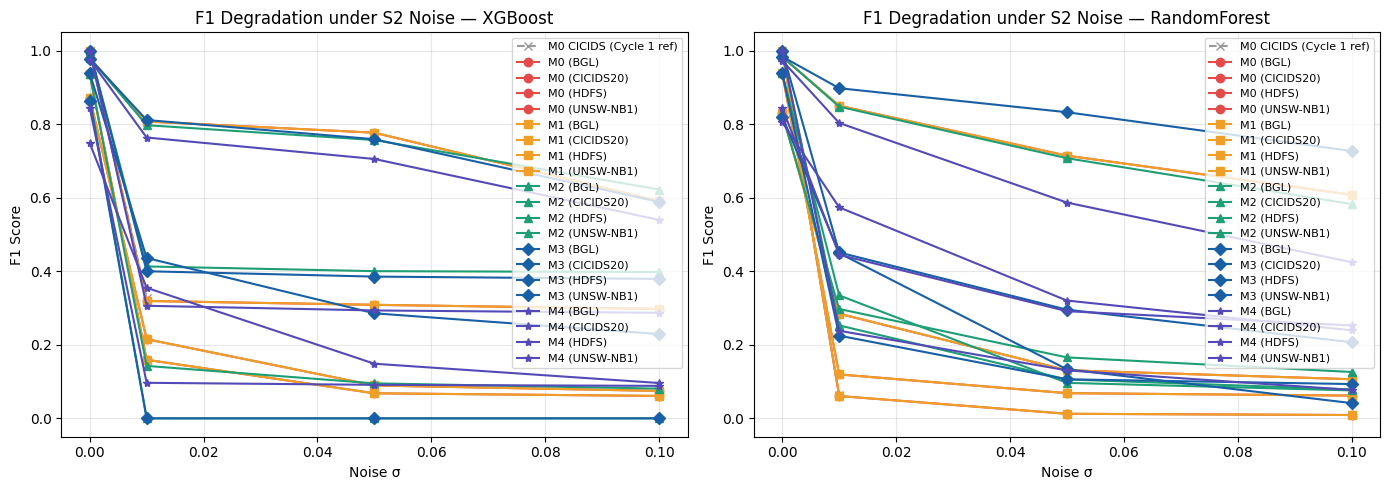

✅ Saved: results/s2_degradation.png


In [21]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
COLS = {'M0':'#E24B4A','M1':'#EF9F27','M2':'#1D9E75','M3':'#185FA5','M4':'#534AB7'}
MRK  = {'M0':'o','M1':'s','M2':'^','M3':'D','M4':'*'}

for ax, mname in zip(axes,['XGBoost','RandomForest']):
    ax.set_title(f'F1 Degradation under S2 Noise — {mname}',fontsize=12)
    ax.set_xlabel('Noise σ'); ax.set_ylabel('F1 Score')
    ax.grid(True,alpha=0.3); ax.set_ylim(-0.05,1.05)

    # Cycle 1 reference
    ref  = C1['XGBoost_S0']      if mname=='XGBoost' else C1['RF_S0']
    ref2 = C1['XGBoost_S2_001']  if mname=='XGBoost' else C1['RF_S2_001']
    ax.plot([0.0,0.01],[ref,ref2],color='#999999',ls='--',
            marker='x',lw=1.5,label='M0 CICIDS (Cycle 1 ref)')

    seen = set()
    for key,exp in sorted(RESULTS.items()):
        cfg = exp['config']
        ds  = exp['dataset']
        if mname not in exp['S0']: continue
        s0  = exp['S0'][mname]['F1']
        sigs= sorted(exp.get('S2',{}).keys())
        s2f = [exp['S2'][s][mname]['F1'] for s in sigs if mname in exp['S2'].get(s,{})]
        if not s2f: continue
        lbl = f"{cfg} ({ds[:8]})"
        if lbl in seen: continue
        seen.add(lbl)
        ax.plot([0.0]+sigs[:len(s2f)],[s0]+s2f,
                marker=MRK.get(cfg,'o'),color=COLS.get(cfg,'gray'),
                label=lbl,lw=1.5)

    ax.legend(fontsize=8,loc='upper right')

plt.tight_layout()
plt.savefig('results/s2_degradation.png',dpi=150,bbox_inches='tight')
plt.show(); print("✅ Saved: results/s2_degradation.png")

## Step 11 — 💾 Download Results

In [22]:
import zipfile
with zipfile.ZipFile('siklus2_results.zip','w') as z:
    for f in Path('results').rglob('*'):
        if f.is_file() and f.suffix in ('.json','.png','.pkl'):
            z.write(f,f.name)

try:
    from google.colab import files
    files.download('siklus2_results.zip')
except: pass

print(f"✅ {len(RESULTS)} results saved")
print("   results/all_results_complete.json")
print("   results/s2_degradation.png")
print("   results/models/*.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 20 results saved
   results/all_results_complete.json
   results/s2_degradation.png
   results/models/*.pkl
